# Example data quickstart

Load bundled FlyWire morphologies with {func}`~neurosetta.load_example_data`,
inspect a {class}`~neurosetta.api.Tree`, and plot a 2D projection.

See also {doc}`io` and the tutorials {doc}`../tutorials/tree_basics`.

**Run in the browser:** [Launch on Binder](https://mybinder.org/v2/gh/NikDrummond/NeuRosetta/main?filepath=docs%2Fgetting_started%2Fexample_data.ipynb)

### Import matplotlib and NeuRosetta

In [1]:
import matplotlib.pyplot as plt
import neurosetta as nr

%matplotlib inline

print(f"neurosetta {nr.__version__}")


neurosetta 0.1.0


### Read in the example data

Here we simply load the example dataset, and then subset out the fist neuron in the forest

In [2]:
EXAMPLE_ID = 720575940596125868

forest = nr.load_example_data()
tree = forest[0]

print(forest)
print(tree)


Forest(n=4, ids=[720575940596125868, 720575940599459782, 720575940599704006, 720575940599729862])
Tree(ID=720575940596125868) with 2010 nodes


### Trees

There are a few core properties of a tree, such as it's id, which is derived from the file name:

In [3]:
tree.ID

720575940596125868

You can also get a simple summary of the tree:

In [4]:
tree.summary()

ID,nodes,branches,leaves,cable,units,isReduced,Flag
720575940596125868,2010,99,111,404.2,micron,False,False


You also have the metadata, which has been updated in the included data to include some usefull information about this particular neuron:

In [5]:
tree.metadata

{'units': 'micron',
 'file_path': '/home/ndrummond@neuro.mpg.de/Code/NeuRosetta/docs/data/nr/720575940596125868.nr',
 'isReduced': False,
 'Neuron_type': 'T5',
 'Neuron_subtype': 'c',
 'Hemisphere': 'R',
 'Flag': False}

The metadata of a neuron is a good way to annotate different features of the neuron. For example, we have added infomation about the neuon type, subtype, and hemisphere from the FlyWire dataset here.

At the core, a Tree is a `graph-tool.Graph` object, which has prroperties bound to it. The undelying graph,and the propeties can be looked at like so:

In [6]:
print(tree.graph)
tree.list_properties()


<Graph object, directed, with 2010 vertices and 2009 edges, 8 internal vertex properties, 2 internal edge properties, 2 internal graph properties, at 0x723cf37b1d90>


{'g': ['ID', 'metadata'],
 'v': ['ids',
  'x',
  'y',
  'z',
  'node_type',
  'radius',
  'subgraph_score',
  'v_subtree_mask'],
 'e': ['Path_length', 'e_subtree_mask']}

You can also get some metics, with some simple examples being:

In [7]:
print(f"nodes:      {tree.count_nodes()}")
print(f"branches:   {tree.count_branches()}")
print(f"leaves:     {tree.count_leaves()}")
print(f"cable len:  {tree.get_total_cable_length():.1f}")


nodes:      2010
branches:   99
leaves:     111
cable len:  404.2


Tree methods also exist as functions with the same name, so the above is equivalent to:

In [8]:
print(f"nodes:      {nr.count_nodes(tree)}")
print(f"branches:   {nr.count_branches(tree)}")
print(f"leaves:     {nr.count_leaves(tree)}")
print(f"cable len:  {nr.get_total_cable_length(tree):.1f}")

nodes:      2010
branches:   99
leaves:     111
cable len:  404.2


You can use whichever is more natual to you. 

Go though {doc}`../tutorials/tree_basics` for more information on the `Tree` class.

### Quick Plotting

You can see examples of plotting in 2-dimensions bellow. You don't actually need to specify an ax object here, or import matplotlib actually. For example `tree.show_2d()` also works fine, but specifying an axes gives you the full flexibility of matplotlib.

NeuRosetta also offes nice 3D plotting functionality, but it opens an external viewer. Have a go with `tree.show_3d()`, but also have a look at {doc}`../tutorials/plotting`.

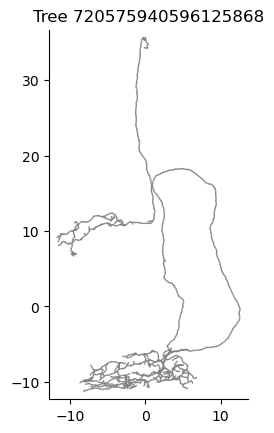

In [9]:
ax = tree.show_2d()
ax.set_title(f"Tree {tree.ID}")
plt.show()


<Axes: ylabel='Tree Depth'>

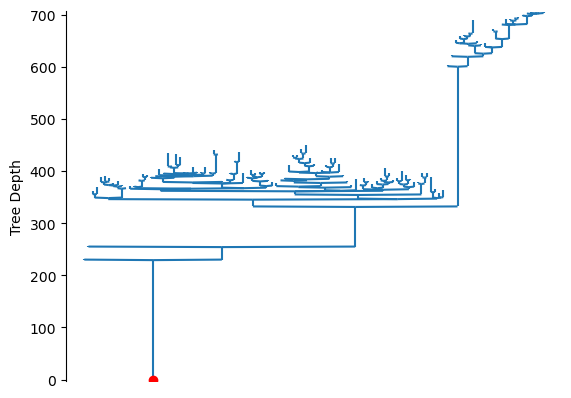

In [10]:
tree.show_dendrogram()


## Forests

We already read in a `Forest` with four neuron trees:

In [11]:
forest

Forest(n=4, ids=[720575940596125868, 720575940599459782, 720575940599704006, 720575940599729862])

Again you have a summay:

In [12]:
forest.summary()

ID,nodes,branches,leaves,cable,units,isReduced,Flag
720575940596125868,2010,99,111,404.2,micron,False,False
720575940599459782,1408,90,99,298.0,micron,False,False
720575940599704006,2043,140,156,429.4,micron,False,False
720575940599729862,2299,149,166,494.6,micron,False,False
TOTAL,7760,478,532,1626.3,micron,,
MEAN,1940,119.5,133,406.6,micron,,


And can get all the same metics:

In [13]:
print(f"nodes: {forest.count_nodes(parallel = False, show_progress = False)}")
print(f"banches: {forest.count_branches(parallel = False, show_progress = False)}")
print(f"leaves: {forest.count_leaves(parallel = False, show_progress = False)}")
print(f"cable length: {forest.get_total_cable_length(parallel = False, show_progress = False)}")


nodes: [2010, 1408, 2043, 2299]
banches: [99, 90, 140, 149]
leaves: [111, 99, 156, 166]
cable length: [404.2379751328887, 298.01680254283934, 429.44516470059705, 494.587506702061]


Note the new `parallel` and `show_progress` kwargs. There is also `max_workers`. For `Forest` operations, NeoRosetta offers multi-threaded parallelisation out of the box, which is a bit pointless on four neurons.

Because of what is going on under the hood, keep in mind that the above mentioned option to use function calls or methods at the uses discretion doesn't work the same way for `Forests`, and instead you need to look into the `Forest.apply` functionality bellow.

### Filtering Forests

